Python Laboratory for Dislocation Dynamics (pyLabDD)

Simple 2D dislocation dynamics demonstration to relax a random dislocation configurations and then analyze their dynamics during shear testing. 

Author: Alexander Hartmaier
Institute: ICAMS / Ruhr-universität Bochum
Date: December 2021

This work is licensed under a Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC-BY-NC-SA)  Creative Commons License

Uses the libraries numpy (http://www.numpy.org/) and matplotlib (https://matplotlib.org/).# Dislocation Dynamics


## 1 Dislocations and stress fields

Provide functions to evaluate stress fields of edge dislocations according to

\begin{equation}
\sigma_{xx} = -\frac{\mu b_x}{2\pi (1-\nu)} \frac{y \left( 3x^2 + y^2 \right)}{\left(x^2 + y^2 \right)^2}
\end{equation}

\begin{equation}
\sigma_{yy} = \frac{\mu b_x}{2\pi (1-\nu)} \frac{y \left(x^2 - y^2 \right)}{\left(x^2 + y^2 \right)^2}
\end{equation}

\begin{equation}
\sigma_{xy} = \frac{\mu b_x}{2\pi (1-\nu)} \frac{x \left(x^2 - y^2 \right)}{\left(x^2 + y^2 \right)^2}
\end{equation}

Note that for the contributions of $b_y$ components of the Burgers verctors, $x$ and $y$ need to be exchanged in all above equations.

Read libraries and declare Python class 'Dislocations' in which all necessary variables and functions are defined and initialized.


In [1]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from pylabdd import Dislocations


## 2 Initialize and relax dislocation configuration, perform dynamic shear test

Define material properties, simulation box and numerical parameters, total number of dislocation, number of mobile dislocations, number and inclination angle of slip planes. After this, the mobile dislocations are allowed to move to a position where the force on them is zero (relaxation step). This is followed by the dynamic shear testing for different dislocation densities and the analysis of the results.

### Note
Here the total dislocation density is varied by changing the size of the box and leaving the total number of dislocations constant. In order to achieve a constant density of mobile dislocations, the number of mobile dislocations is adapted according to the box size.


Configuration: 120 dislocations 80 mobile dislocations
box size: 200.0 micron x  200.0 micron
total dislocation density:  0.003 /micron^2
mobile dislocation density:  0.002 /micron^2


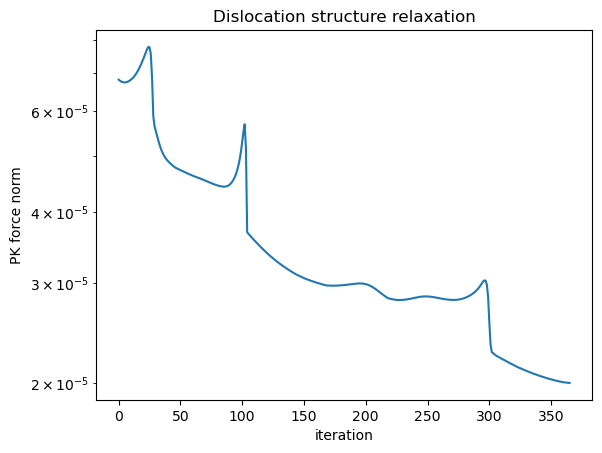

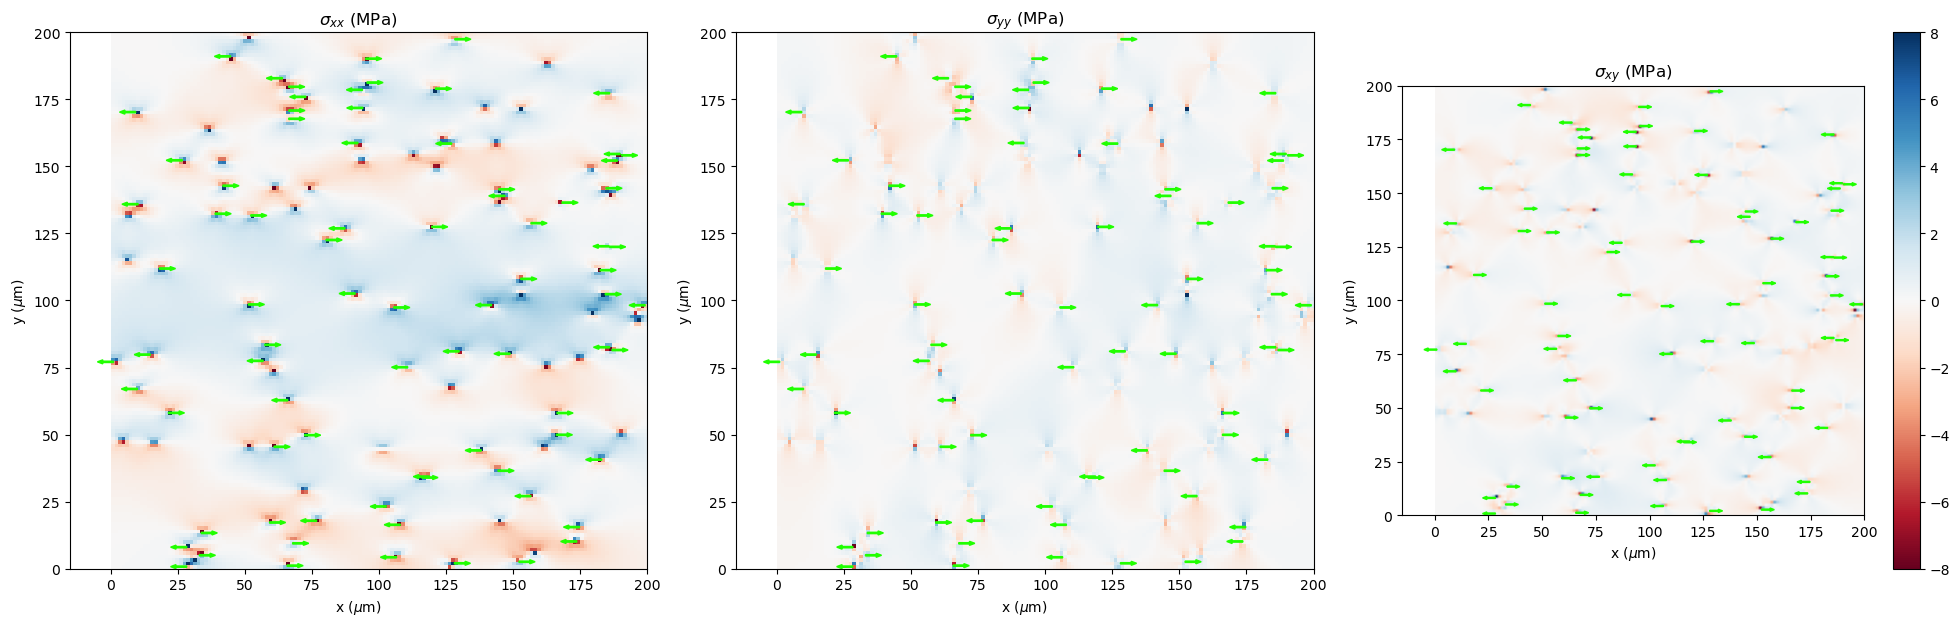

Relaxed dislocation configuration

Virtual dynamic tensile test with loading rate  0.09999999999999999 /s
Performing 100000 iterations with initial sim_time step 0.05

Iteration 	| stress 	| plastic strain 	| Time step 
---------------------------------------------------------------------------------
10000		| 1.79020	| 4.11973e-04		| 0.38355


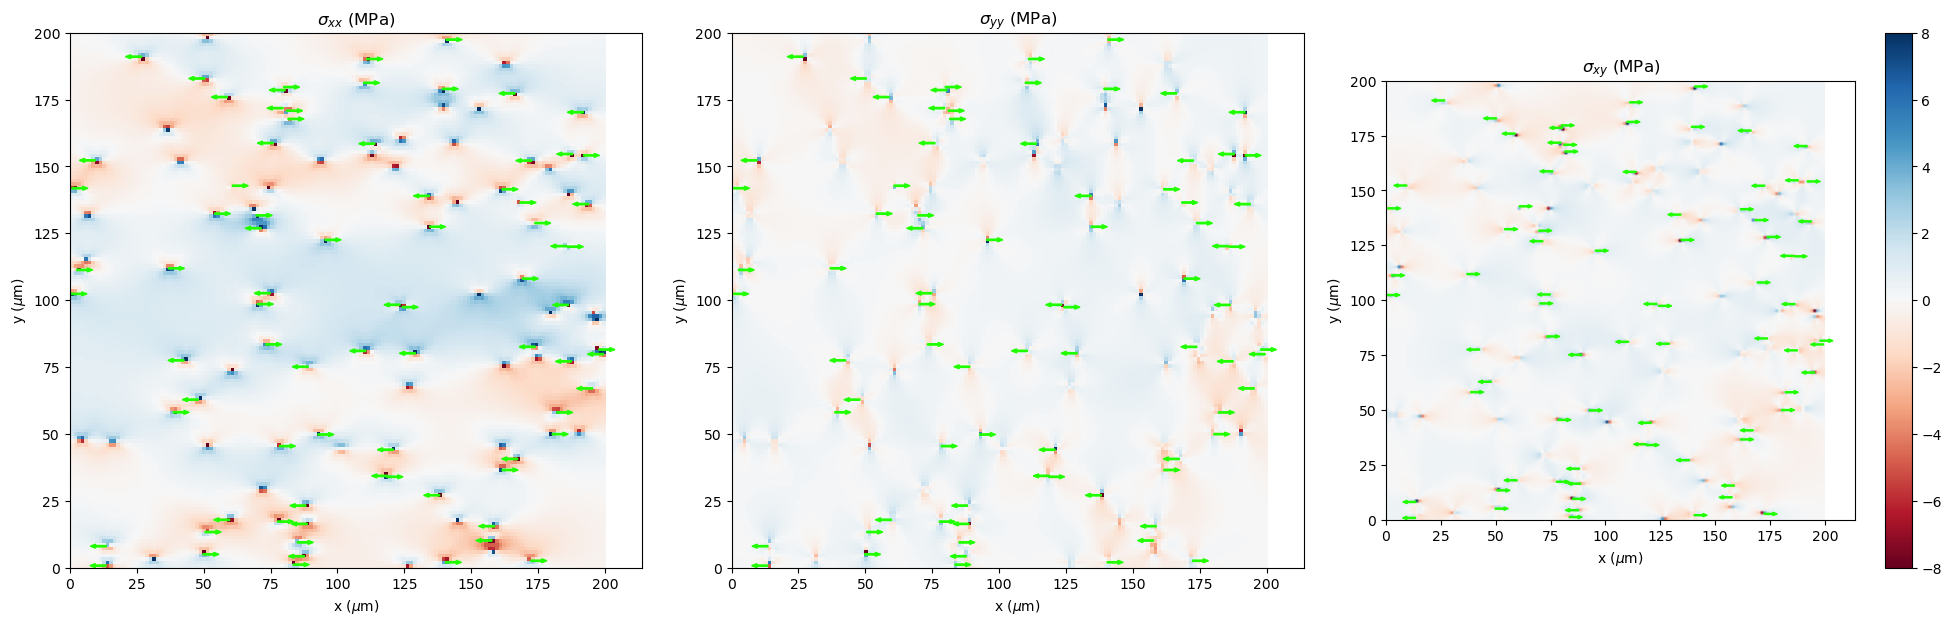

Configuration after 11800 iterations at total strain 0.0005000275189119014
Time step in last iteration:  0.41768190339579025


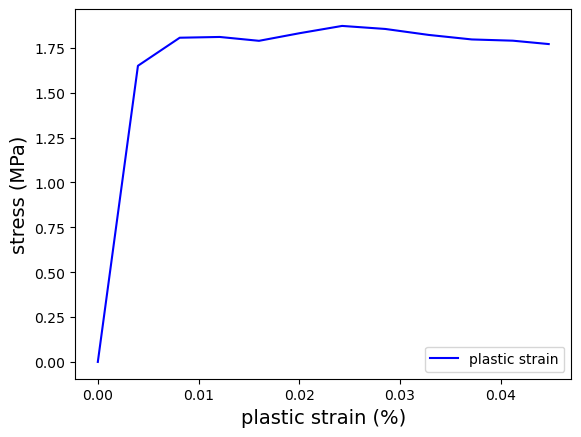


Configuration: 120 dislocations 45 mobile dislocations
box size: 150.0 micron x  150.0 micron
total dislocation density:  0.005333333333333333 /micron^2
mobile dislocation density:  0.002 /micron^2


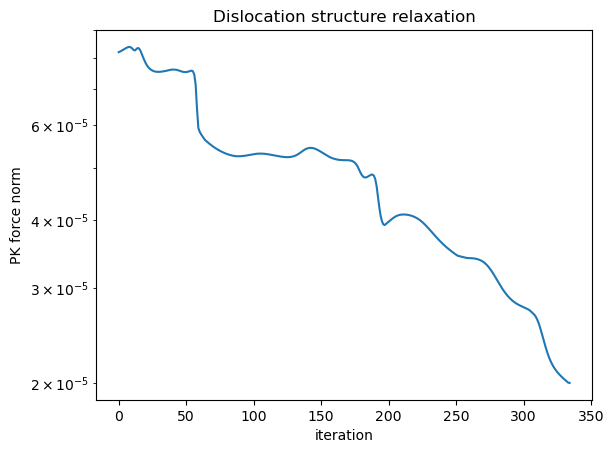

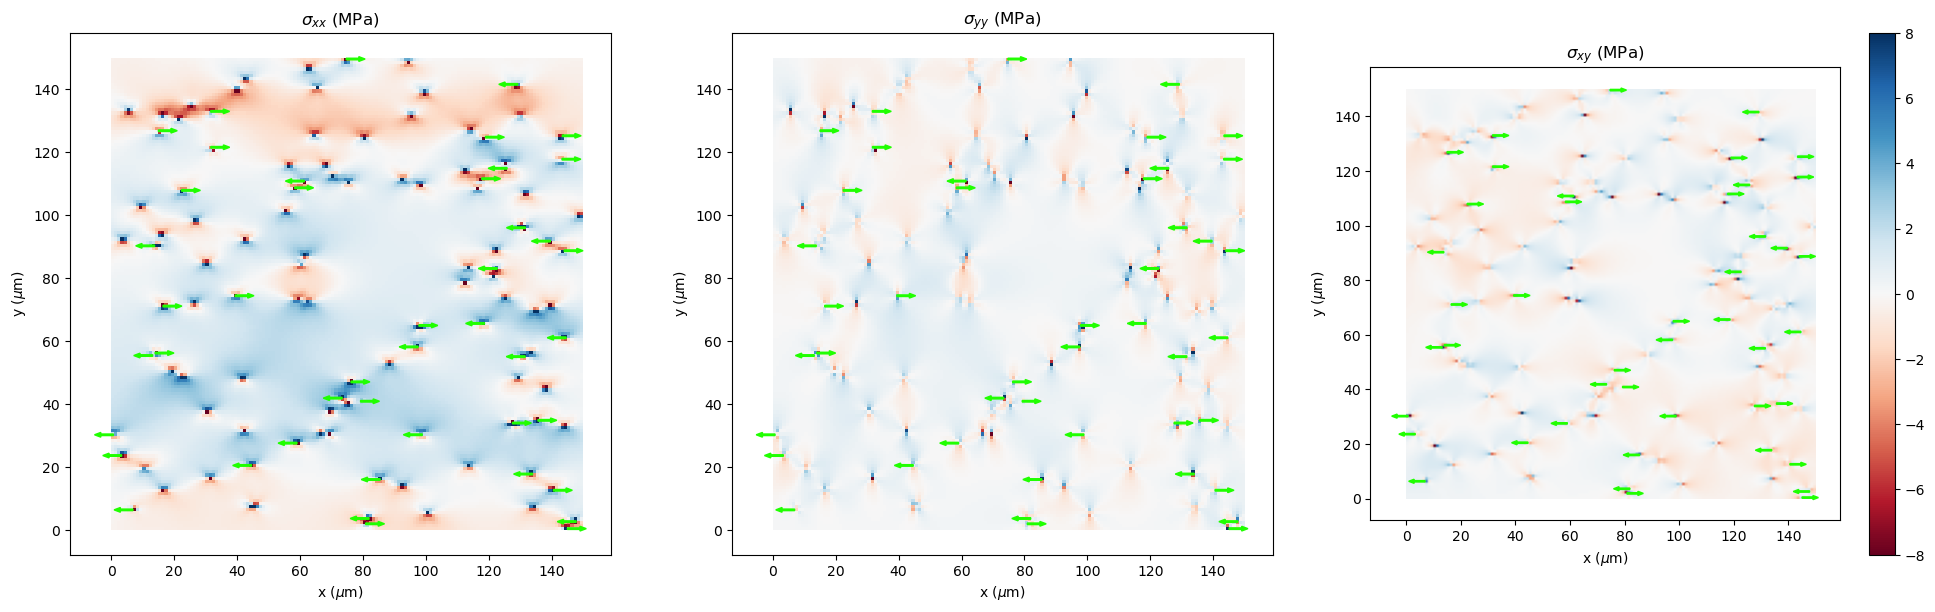

Relaxed dislocation configuration

Virtual dynamic tensile test with loading rate  0.09999999999999999 /s
Performing 100000 iterations with initial sim_time step 0.05

Iteration 	| stress 	| plastic strain 	| Time step 
---------------------------------------------------------------------------------
10000		| 3.16523	| 2.56985e-04		| 0.25419


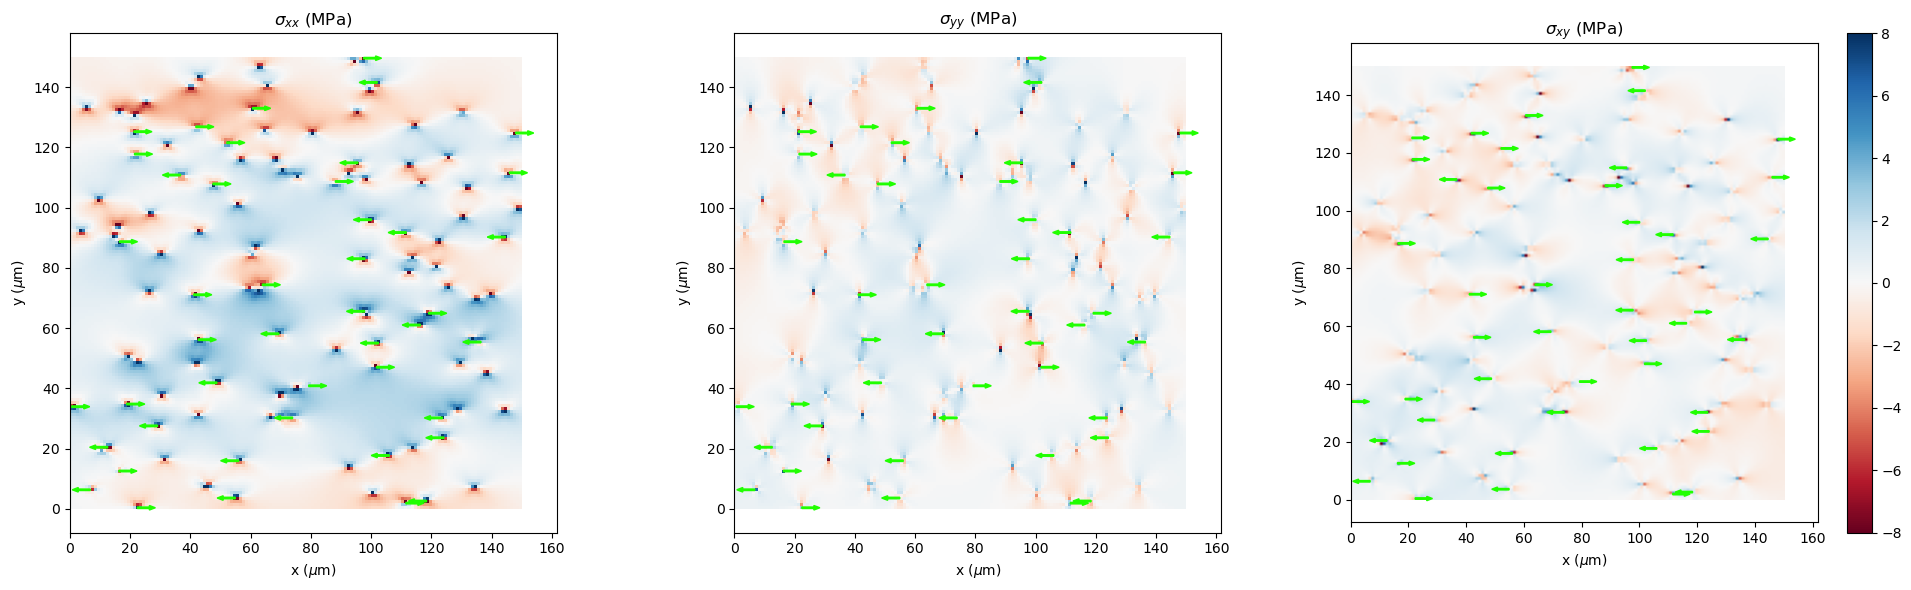

Configuration after 18573 iterations at total strain 0.000500016356615424
Time step in last iteration:  0.22876792454961012


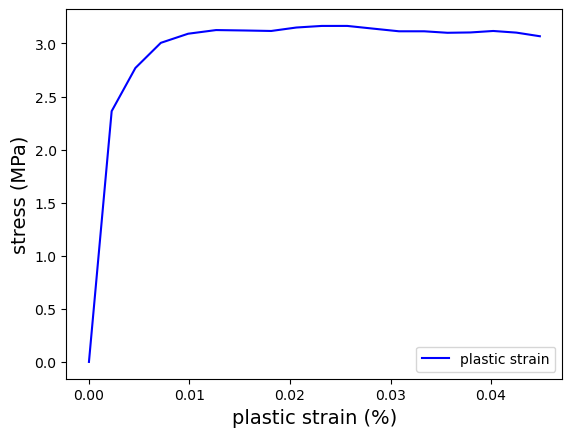


Configuration: 120 dislocations 20 mobile dislocations
box size: 100.0 micron x  100.0 micron
total dislocation density:  0.012 /micron^2
mobile dislocation density:  0.002 /micron^2


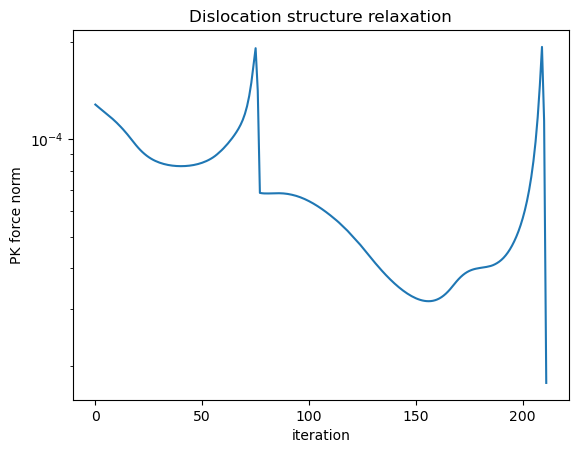

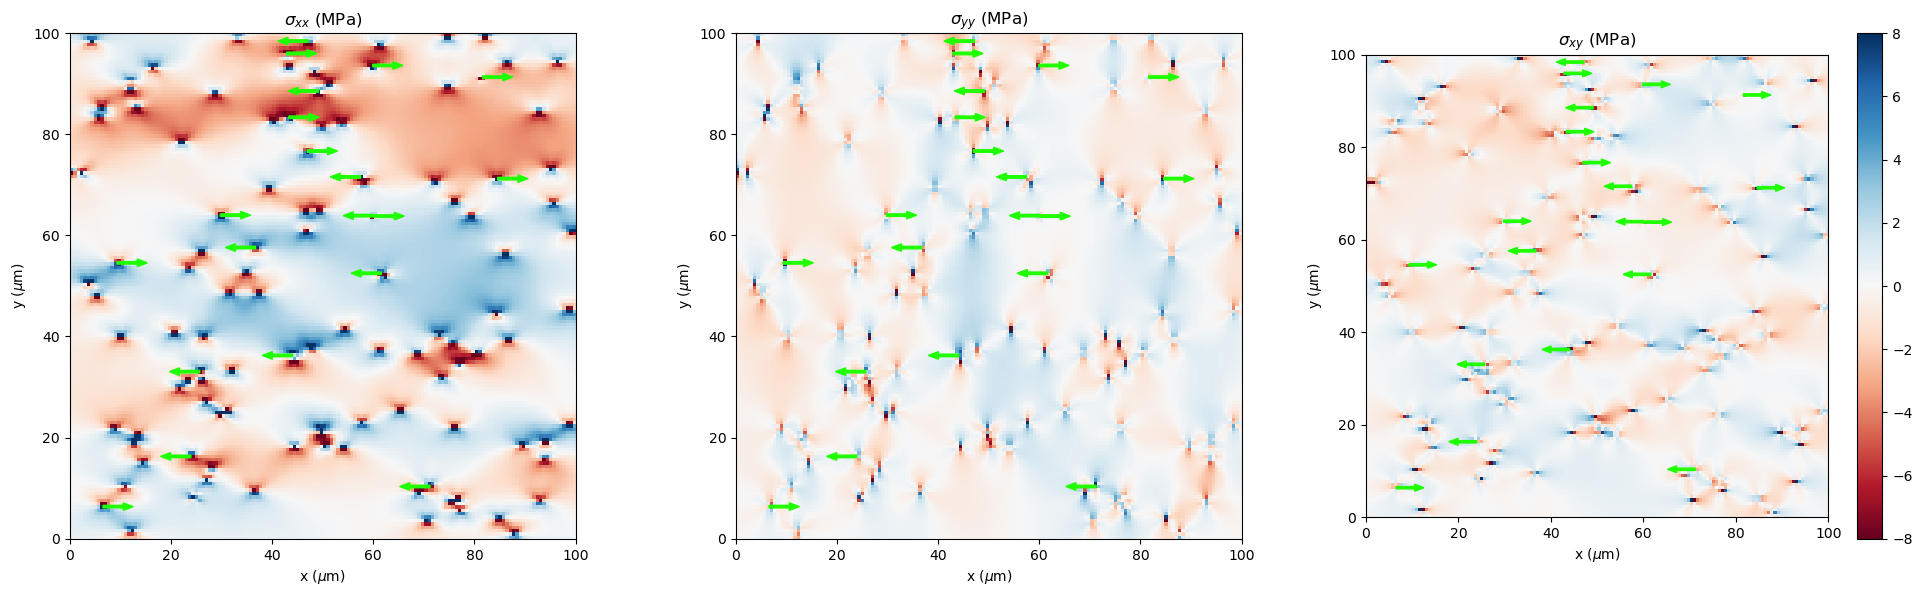

Relaxed dislocation configuration

Virtual dynamic tensile test with loading rate  0.09999999999999999 /s
Performing 100000 iterations with initial sim_time step 0.05

Iteration 	| stress 	| plastic strain 	| Time step 
---------------------------------------------------------------------------------
10000		| 6.64904	| 1.08491e-04		| 0.12158
20000		| 7.17801	| 2.21705e-04		| 0.12036
30000		| 7.28857	| 3.34232e-04		| 0.10724


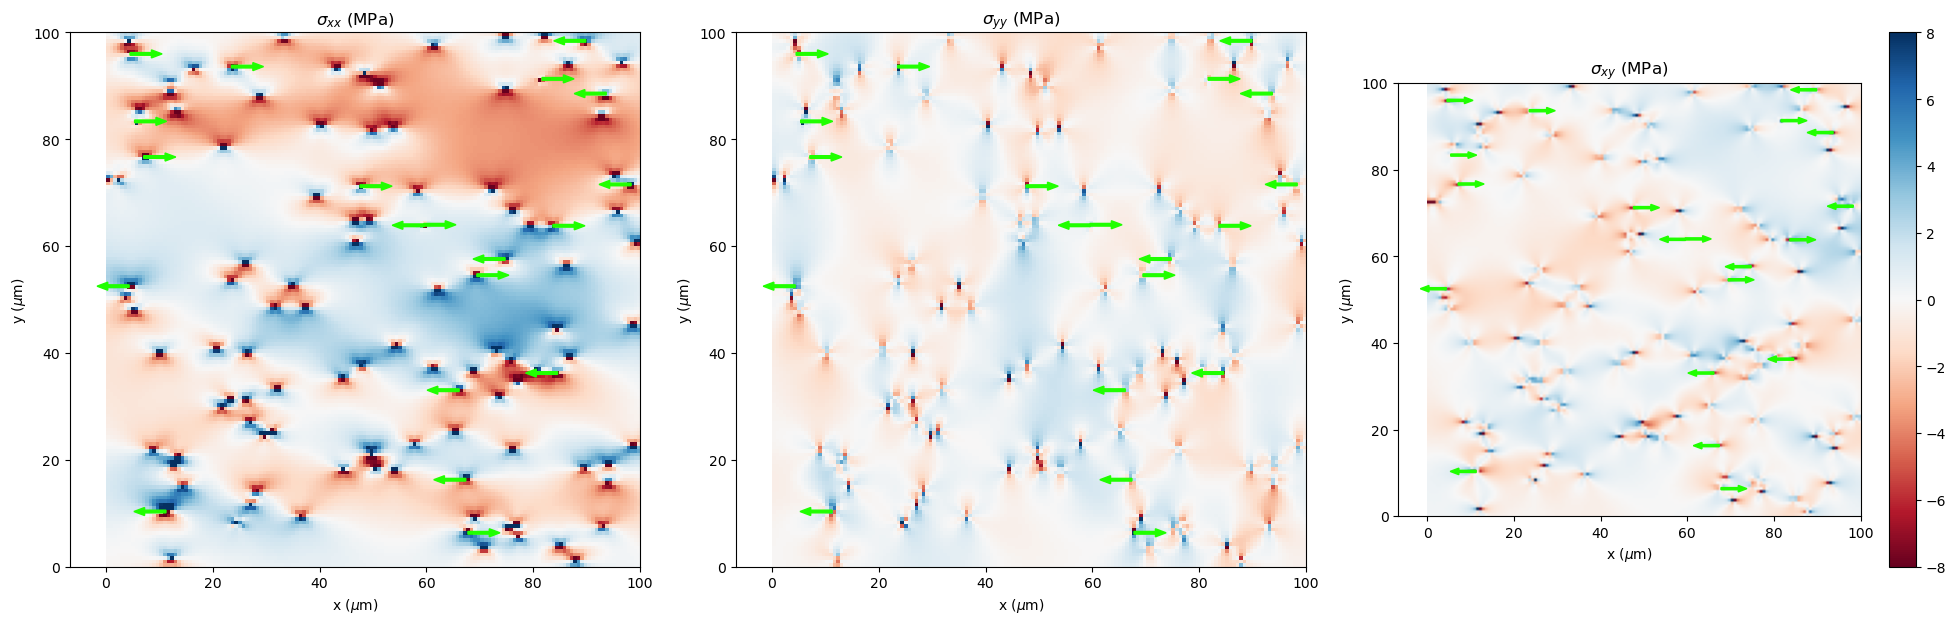

Configuration after 36684 iterations at total strain 0.0005000077328370465
Time step in last iteration:  0.10616913573531742


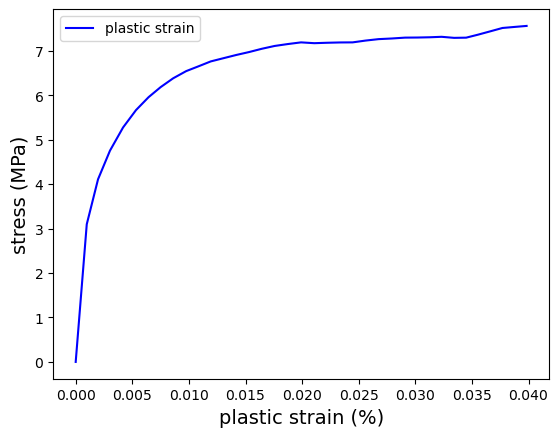


Configuration: 120 dislocations 9 mobile dislocations
box size: 70.0 micron x  70.0 micron
total dislocation density:  0.024489795918367346 /micron^2
mobile dislocation density:  0.001836734693877551 /micron^2


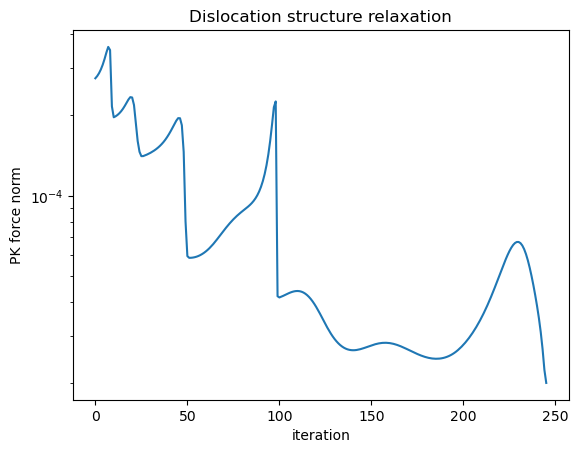

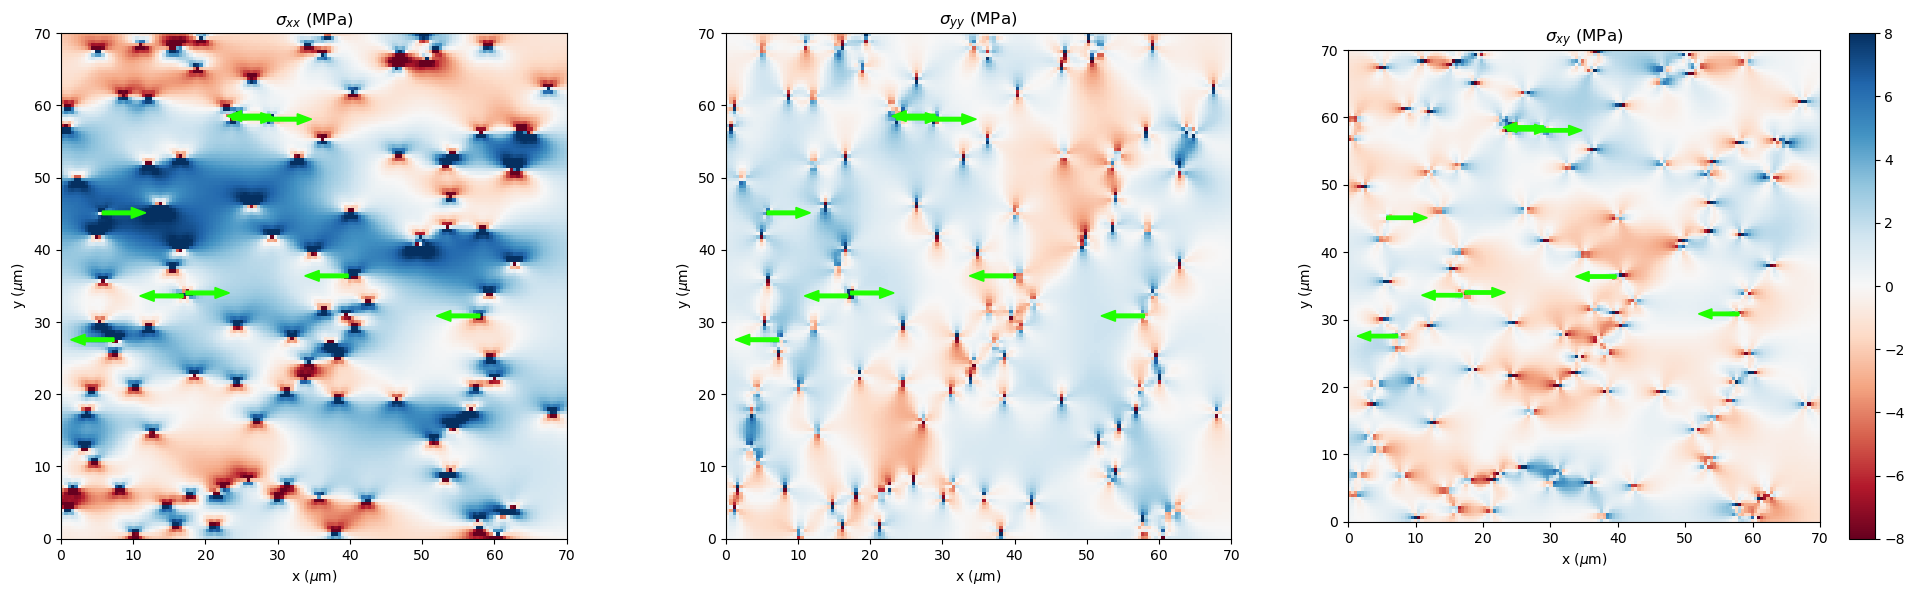

Relaxed dislocation configuration

Virtual dynamic tensile test with loading rate  0.09999999999999999 /s
Performing 100000 iterations with initial sim_time step 0.05

Iteration 	| stress 	| plastic strain 	| Time step 
---------------------------------------------------------------------------------
10000		| 9.43372	| 4.55478e-05		| 0.09848
20000		| 11.69964	| 1.02927e-04		| 0.07179
30000		| 13.26525	| 1.53951e-04		| 0.06461
40000		| 14.11688	| 2.06734e-04		| 0.05815
50000		| 14.80433	| 2.59567e-04		| 0.06333


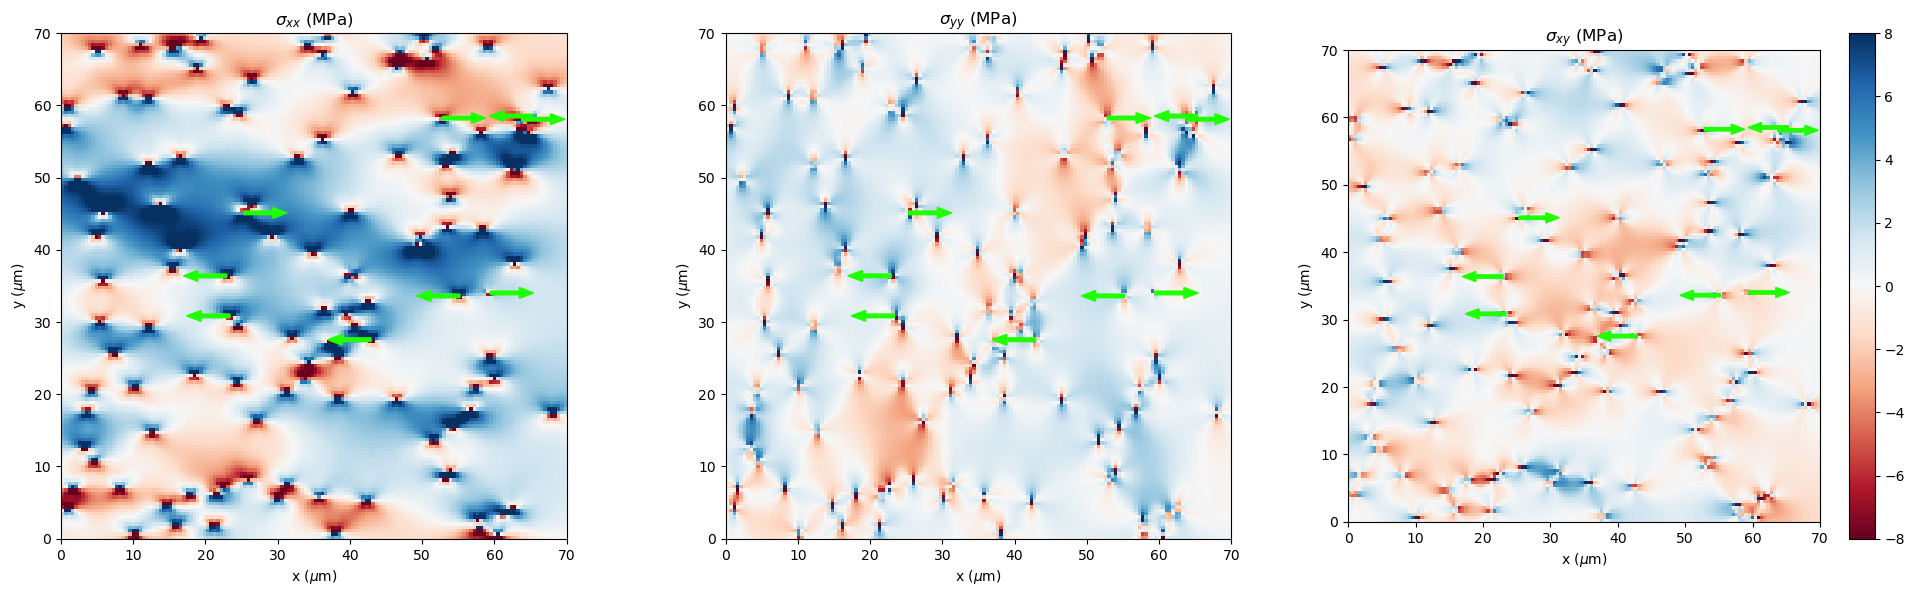

Configuration after 58988 iterations at total strain 0.0005000051066631688
Time step in last iteration:  0.05699255723667963


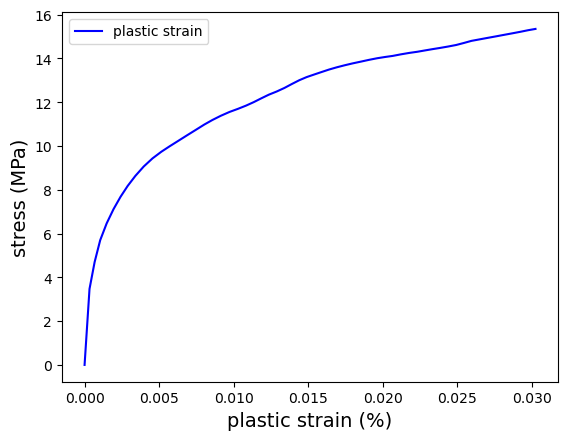

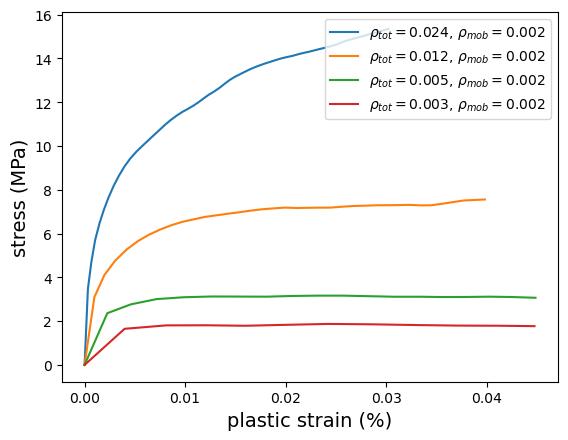

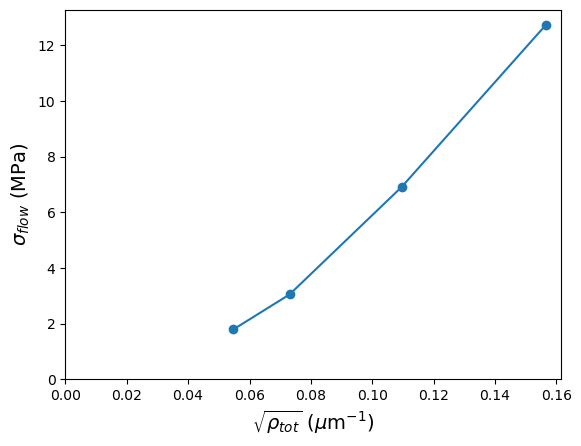

In [3]:
#define material parameters
#units: stress: MPa; length: micron; sim_time: microseconds
mu = 80.0e3          # shear modulus
nu = 0.3             # Poisson ratio
b0 = 0.2e-3          # Burgers vector norm
C = mu*b0/(2*np.pi*(1.-nu))   # Constant for dislocation stress field
f0 = 10.             # initial slip resistance
mob = 100.           # dislocation mobility

moblaw = 'viscous'   # set mobility law used for dislocation motion: 'viscous' or 'powerlaw'
Ntot = 120
spang = 0.

#set strain parameters
edot = 0.1e-6  # strain rate (per microsecond), vary between 1.e-8 and 1.e-5
efin = 0.0005   # final strain
nstep = 100000  # max number of steps (int(efin/(edot*dt*100.))*1000 )
idat = int(nstep/100) # frequency of data storage
ipl  = 10*idat # frequency of plotting
dt0 = 5.e-9/edot  #0.03    # values up to 0.05 yield similar results
dt = dt0

#box geometry
bc = 'pbc'            # set boundary conditions: 'fixed' or 'pbc'
dim = [200, 150, 100, 70] # dimensions of square-shaped simulation boxes to be used

#initialze random number generator
np.random.seed(110)  # seed RNG
rt_rho = []
sy = []
eps = []
sig = []
label = []

for i, hd in enumerate(dim):
    #define dislocations
    Nmob = int(2.e-3*dim[i]**2)  # keep density of mobile dislocations constant
    dsl = Dislocations(Ntot, Nmob, spang, C, b0, 
                       LX=dim[i], LY=dim[i], bc=bc, 
                       f0=f0, dmob=mob) 
    dsl.positions(stol=1.e-4)   # initialize positions randomly
    print('\n===============================================================')
    print('Configuration:', dsl.Ntot,'dislocations', dsl.Nmob,'mobile dislocations')
    print('box size:',dsl.lx,'micron x ',dsl.ly,'micron')
    print('total dislocation density: ',dsl.rho,'/micron^2')
    print('mobile dislocation density: ',dsl.rho_m,'/micron^2')

    dsl.relax_disl(ftol=2.e-5, plot_conf=False)  # relax dislocations into force equilibrium
    dsl.plot_stress()
    print('Relaxed dislocation configuration\n')
    print('Virtual dynamic tensile test with loading rate ',edot*1e6,'/s')
    print('Performing',nstep,'iterations with initial sim_time step', dt0)
    print('\nIteration \t| stress \t| plastic strain \t| Time step ')
    print('---------------------------------------------------------------------------------')
    #initialize variables
    tau0 = 0.     # macro shear stress
    epl  = 0.     # plastic strain
    etot = 0.     # total strain
    sig_m = [0.]   # initialize list for stress values for postprocessing 
    epl_m = [0.]
    eps_m = [0.]
    ic = 0
    Cpl = dsl.rho_m*b0  # prefactor for Orowan law
    # start main loop
    while etot<efin and ic<nstep:
        etot +=edot*dt
        tau0 = mu*(etot-epl)
        fsp, dt = dsl.move_disl(tau0, Nmob, moblaw, dt)
        #calculate plastic slip
        dgpl = Cpl*(np.dot(dsl.dx,dsl.bx) + np.dot(dsl.dy,dsl.by))
        epl += dgpl
        if epl>etot:
            print('Warning: check sim_time step', ic, dgpl, tau0, epl, etot, f0)
        ic += 1
        if ic%idat==0:
            sig_m.append(tau0)
            eps_m.append(etot)
            epl_m.append(epl)
            if ic%ipl==0:
                #dsl.plot_stress()
                print(f'{ic}\t\t| {tau0:.5f}\t| {epl:.5e}\t\t| {dt:.5f}')
    dsl.plot_stress() 
    print('Configuration after',ic,'iterations at total strain',etot)
    print('Time step in last iteration: ',dt) 
    
    epl_m = np.array(epl_m)
    sig_m = np.array(sig_m)
    eps_m = np.array(eps_m)
    plt.plot(epl_m*100,sig_m,'b',label='plastic strain')
    plt.xlabel('plastic strain (%)',fontsize=14)
    plt.ylabel('stress (MPa)',fontsize=14)
    plt.legend()
    plt.show()
    
    eps.append(epl_m)
    sig.append(sig_m)
    rt_rho.append(np.sqrt(dsl.rho))
    i0 = int(len(sig_m)*0.1)
    sy.append(np.average(sig_m[i0:]))
    label.append(r'$\rho_{tot}=$'+f'{dsl.rho:.3f}, '+r'$\rho_{mob}=$'+f'{dsl.rho_m:.3f}')

#plot stress strain curves
for i in range(len(dim)-1,-1,-1):
    plt.plot(eps[i]*100,sig[i],label=label[i])
plt.xlabel('plastic strain (%)',fontsize=14)
plt.ylabel('stress (MPa)',fontsize=14)
plt.legend()
plt.show()

#plot flow stress against sqrt of total disl. density
plt.plot(rt_rho,sy,'-o')
plt.xlim(left=0.)
plt.ylim(bottom=0.)
plt.xlabel(r'$\sqrt{\rho_{tot}}$ ($\mu$m$^{-1}$)',fontsize=14)
plt.ylabel(r'$\sigma_{flow}$ (MPa)',fontsize=14)
plt.show()


It is seen that the Taylor law is fulfilled in the sense that the flow stress, i.e. the stress level at which the material follows the applied strain rate, increases proportionally to the square root of the total dislocation density. It is also seen that the internal stresses are higher for higher dislocation densities such that the mobile dislocations need to overcome higher barriers.

## 3 Virtual shear testing with varying number of dislocations

In this part the dislocation configuration is created in a similar way as before. However, the variation of the dislocation density is achieved by varying the total number of dislocations is a box of constant size. The number of mobile dislocations is kept constant such that the same density of mobile dislocations is achieved as above. Note, that in this way the effort to reach higher dislocation densities growth overproportionally because the number of calculations is $N_\mathrm{mob} N_\mathrm{tot}$.



Configuration: 10 dislocations 10 mobile dislocations
box size: 70.71 micron x  70.71 micron
total dislocation density:  0.0020000383607357594 /micron^2
mobile dislocation density:  0.0020000383607357594 /micron^2


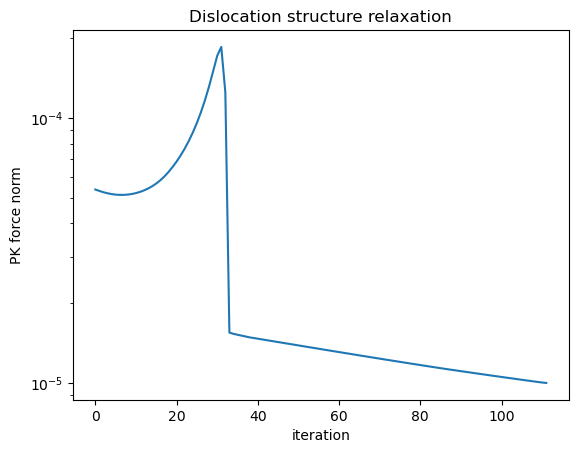

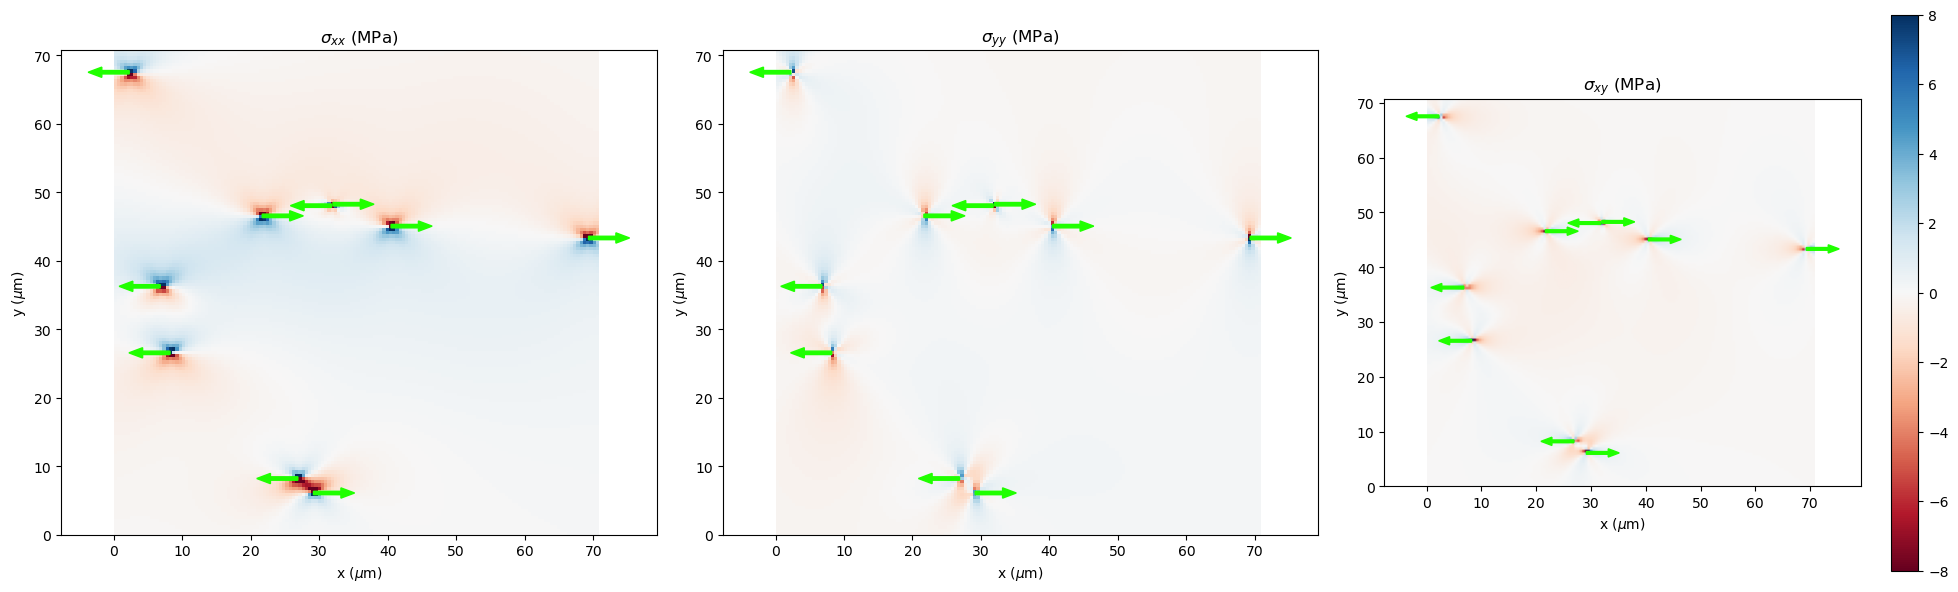

Relaxed dislocation configuration

Virtual dynamic tensile test with loading rate  0.09999999999999999 /s
Performing 100000 iterations with initial sim_time step 0.05

Iteration 	| stress 	| plastic strain	| Time step 
---------------------------------------------------------------------------------
10000		| 8.69693	| 6.97606e-05		| 0.10942
20000		| 10.40730	| 1.44057e-04		| 0.08863
30000		| 11.35734	| 2.20015e-04		| 0.07977
40000		| 11.78640	| 2.94418e-04		| 0.07977


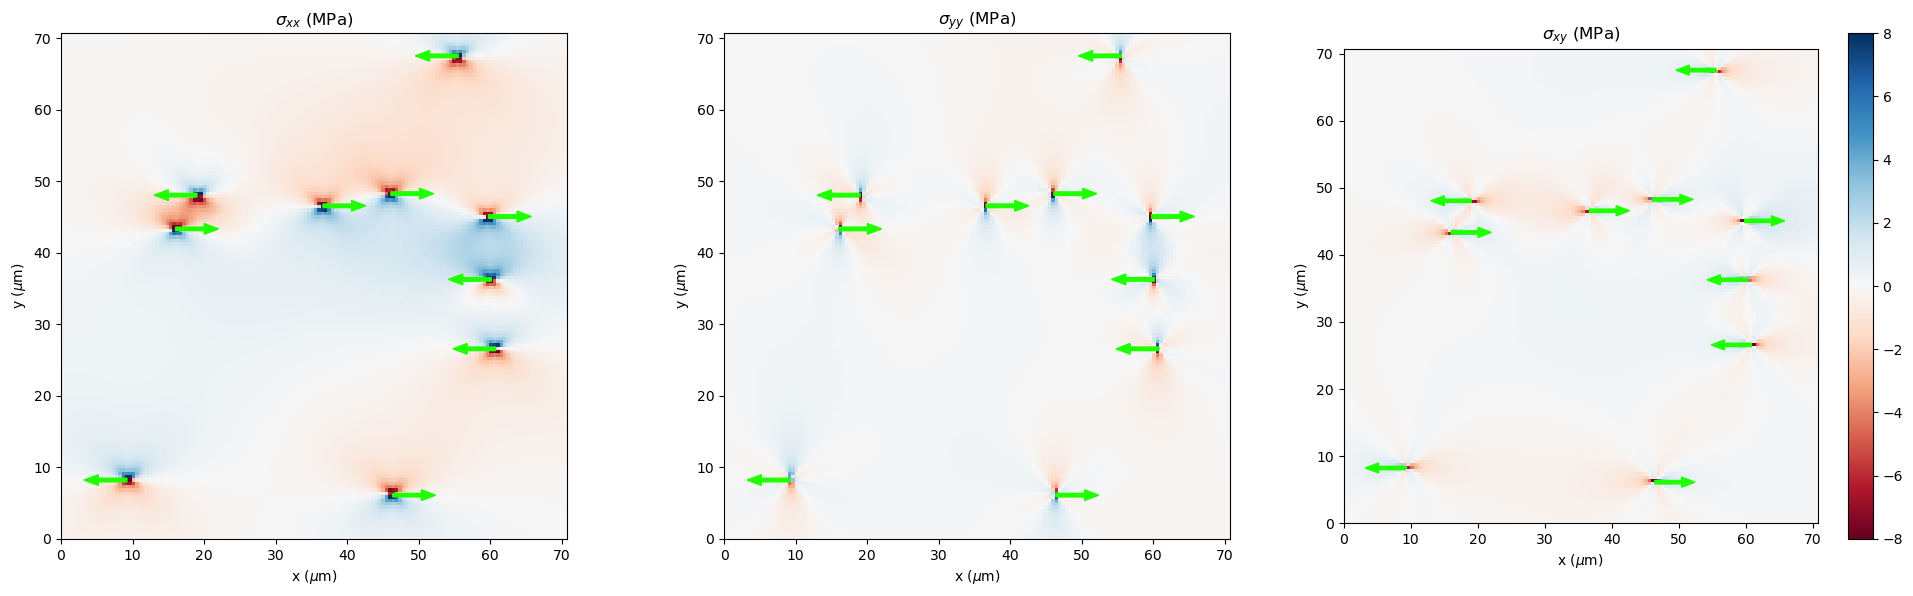

Configuration after 47304 iterations at total strain 0.000500002022422811
Time step in last iteration:  0.07976644307687257


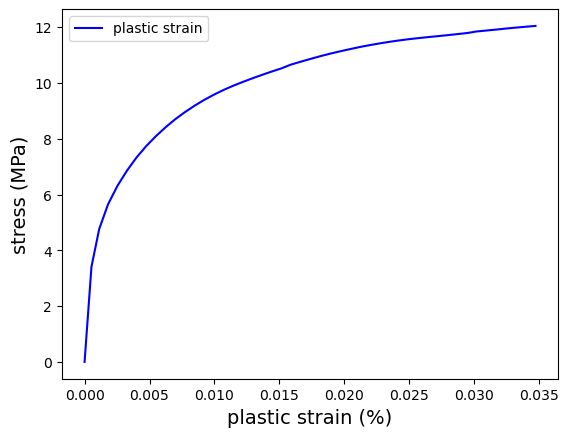


Configuration: 30 dislocations 10 mobile dislocations
box size: 70.71 micron x  70.71 micron
total dislocation density:  0.006000115082207278 /micron^2
mobile dislocation density:  0.0020000383607357594 /micron^2


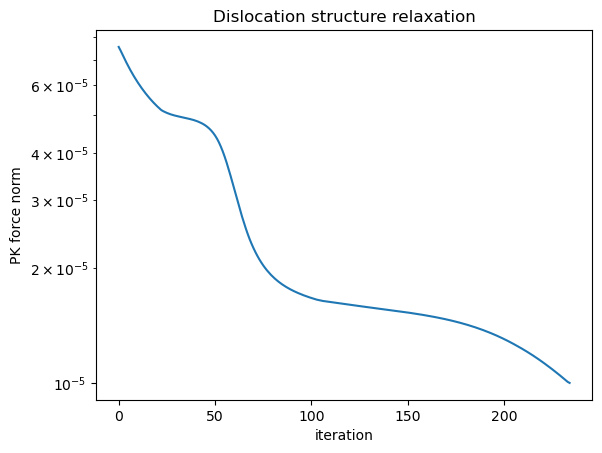

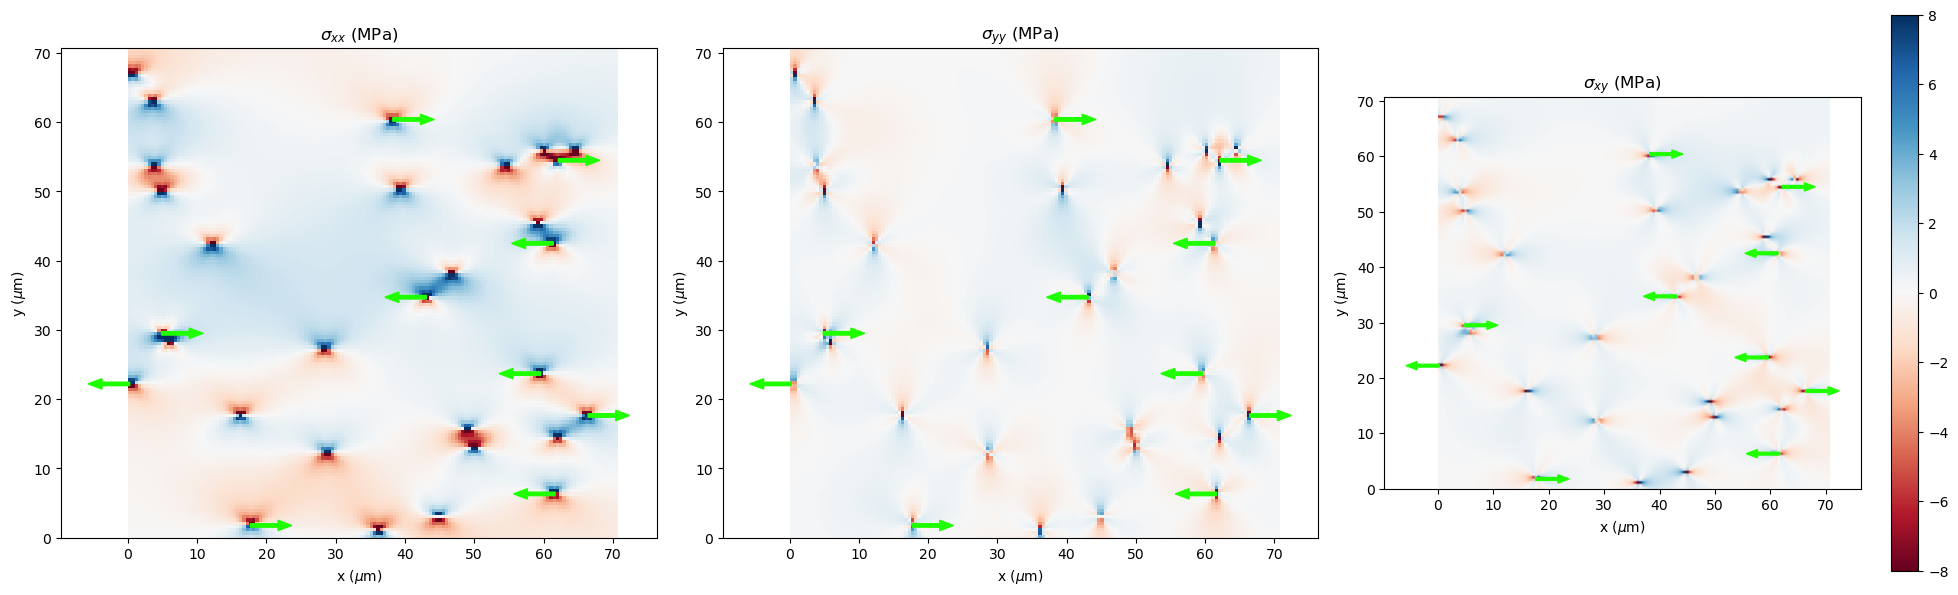

Relaxed dislocation configuration

Virtual dynamic tensile test with loading rate  0.09999999999999999 /s
Performing 100000 iterations with initial sim_time step 0.05

Iteration 	| stress 	| plastic strain	| Time step 
---------------------------------------------------------------------------------
10000		| 8.73277	| 7.24242e-05		| 0.10942
20000		| 10.90685	| 1.39584e-04		| 0.08863
30000		| 12.13751	| 2.04949e-04		| 0.07179
40000		| 12.70461	| 2.69651e-04		| 0.07179


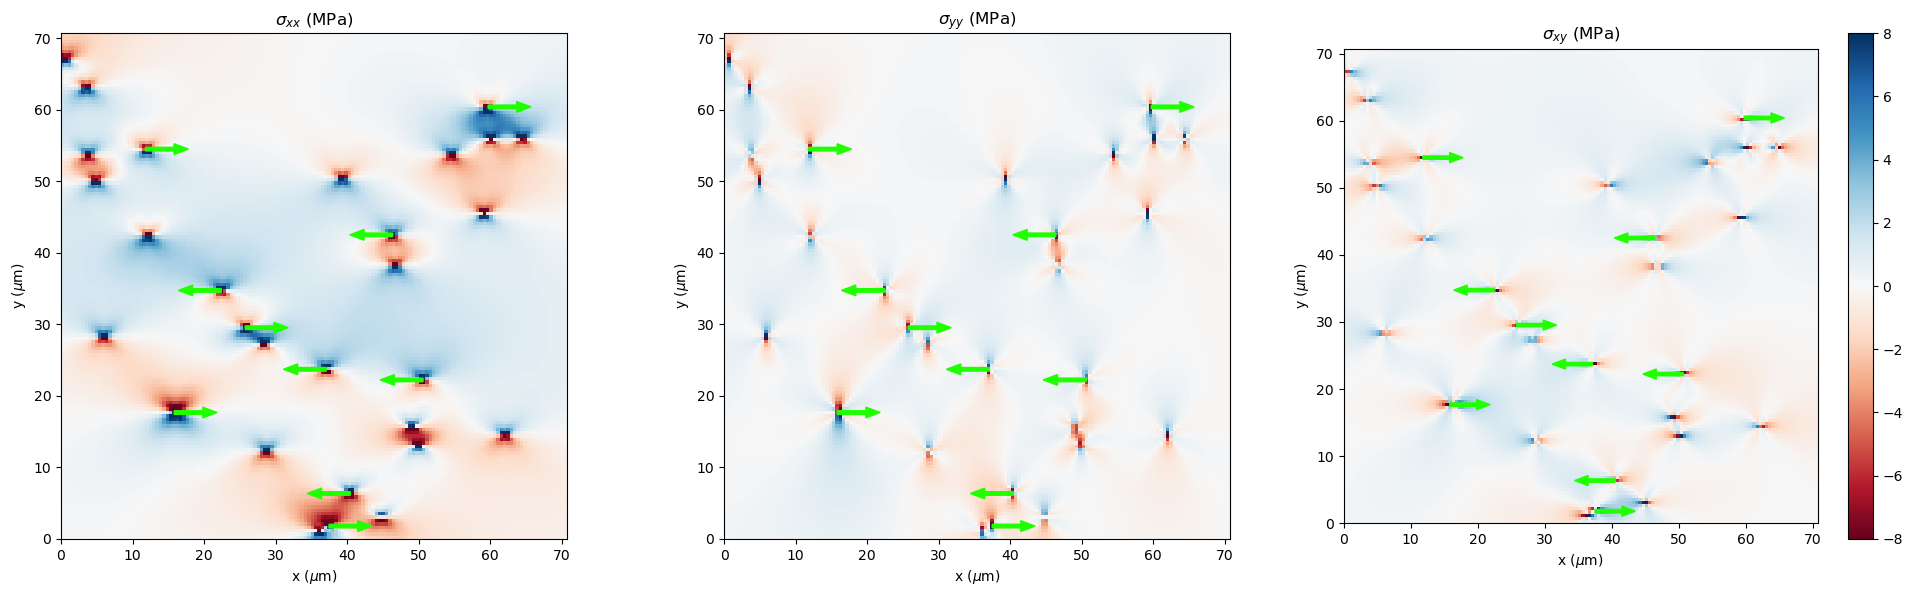

Configuration after 49967 iterations at total strain 0.0005000050112134983
Time step in last iteration:  0.07178979876918531


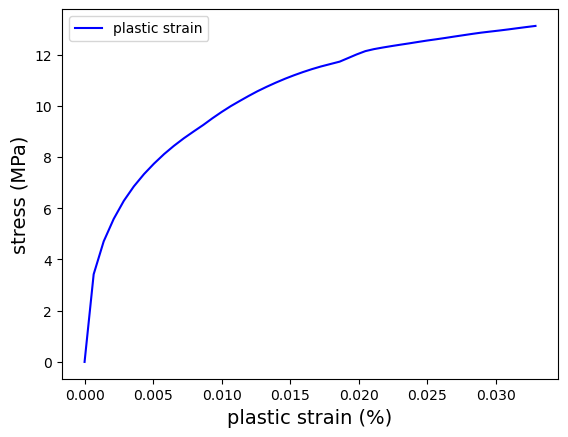


Configuration: 90 dislocations 10 mobile dislocations
box size: 70.71 micron x  70.71 micron
total dislocation density:  0.018000345246621835 /micron^2
mobile dislocation density:  0.0020000383607357594 /micron^2


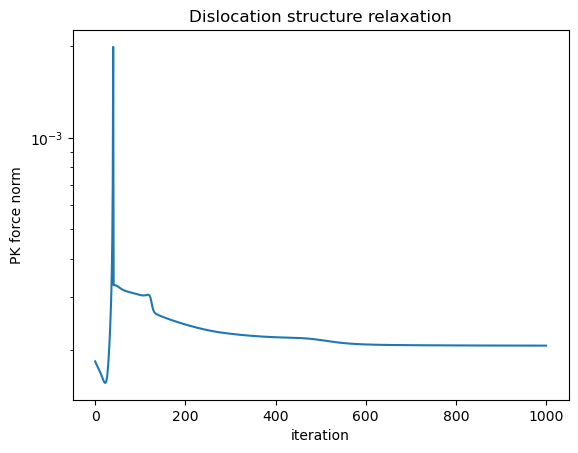

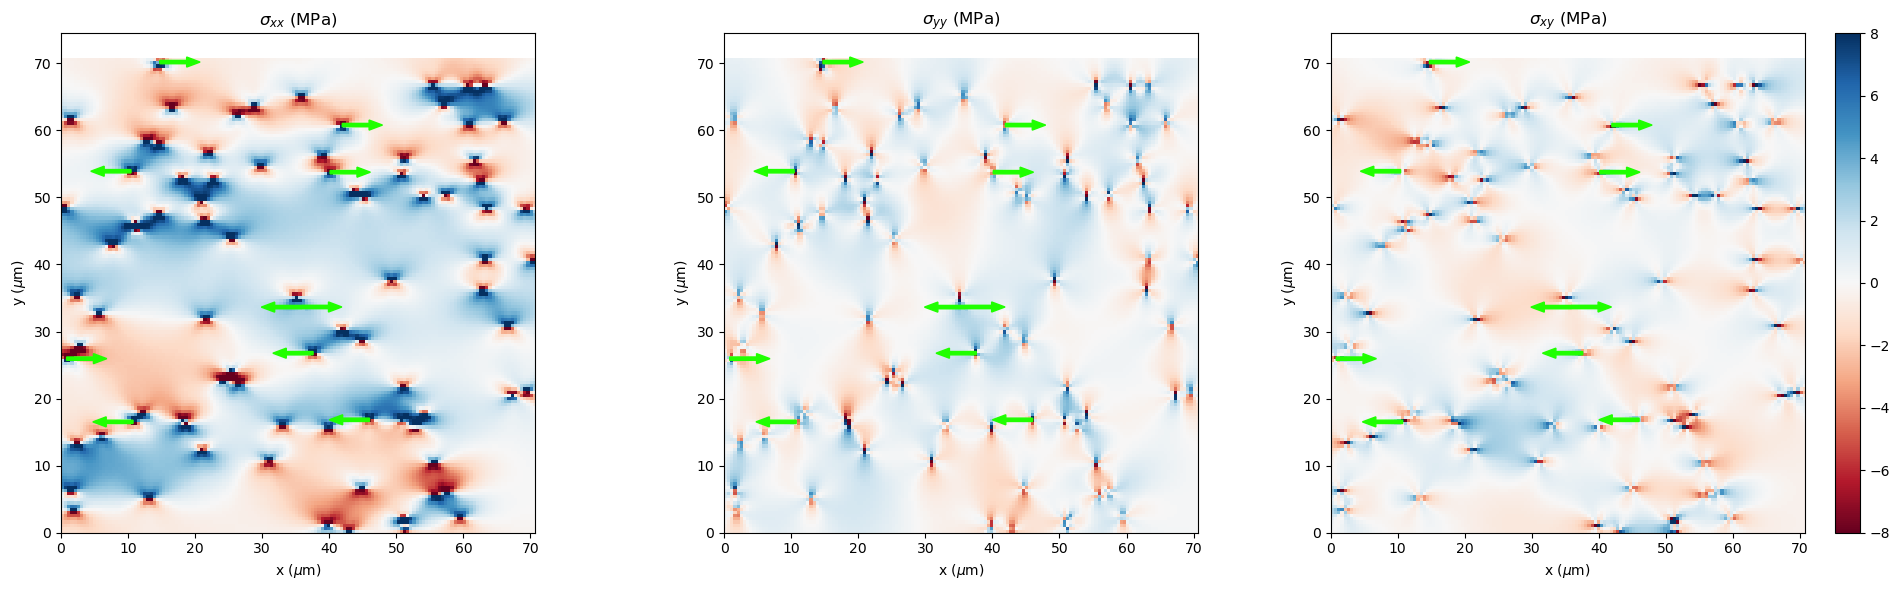

Relaxed dislocation configuration

Virtual dynamic tensile test with loading rate  0.09999999999999999 /s
Performing 100000 iterations with initial sim_time step 0.05

Iteration 	| stress 	| plastic strain	| Time step 
---------------------------------------------------------------------------------
10000		| 7.17184	| 2.59584e-05		| 0.11562
20000		| 10.38945	| 7.54769e-05		| 0.08015
30000		| 12.99079	| 1.24414e-04		| 0.07070
40000		| 14.13580	| 1.75619e-04		| 0.06300
50000		| 15.03730	| 2.27348e-04		| 0.06300
60000		| 15.84137	| 2.78034e-04		| 0.06237


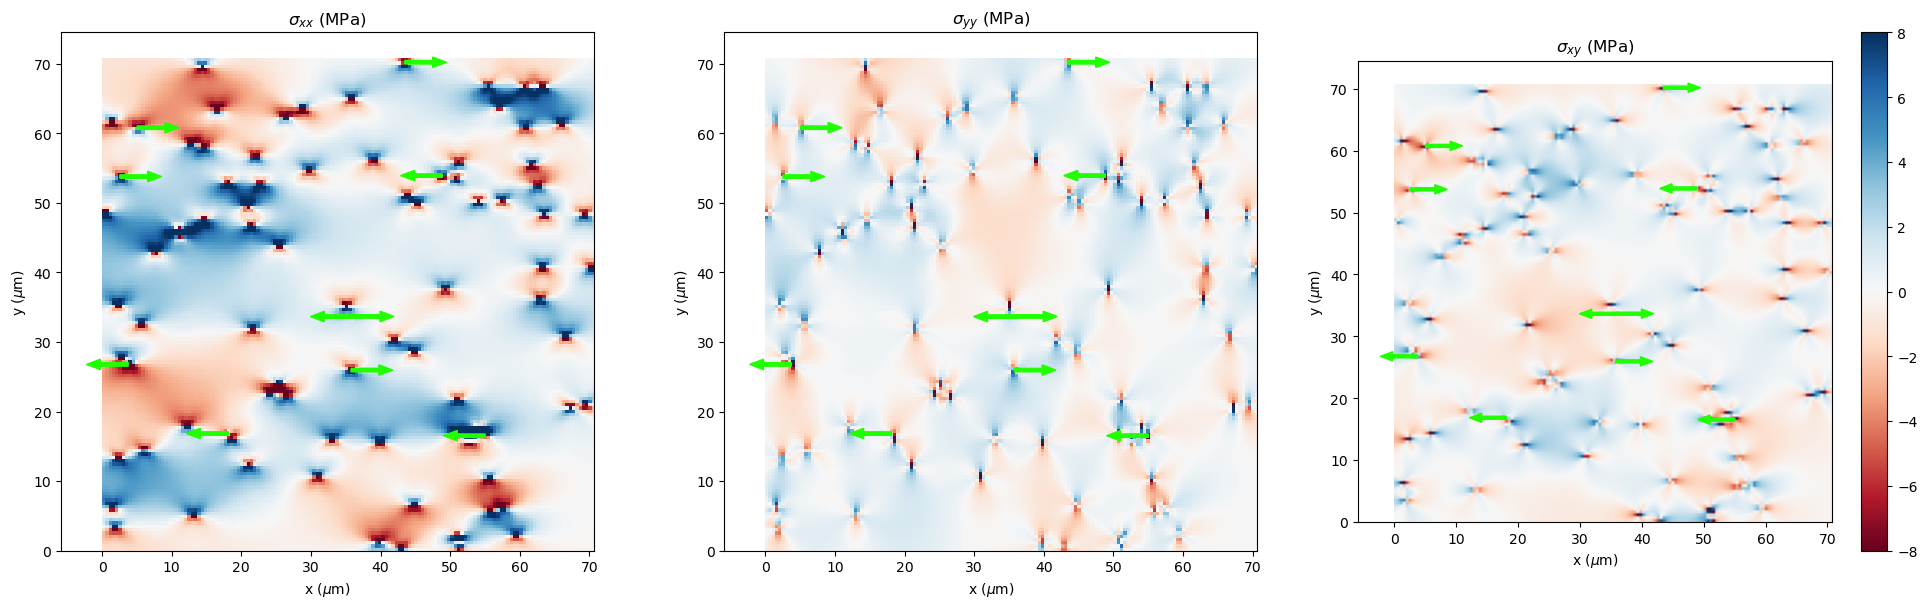

Configuration after 63841 iterations at total strain 0.0005000008379659361
Time step in last iteration:  0.06236708708025741


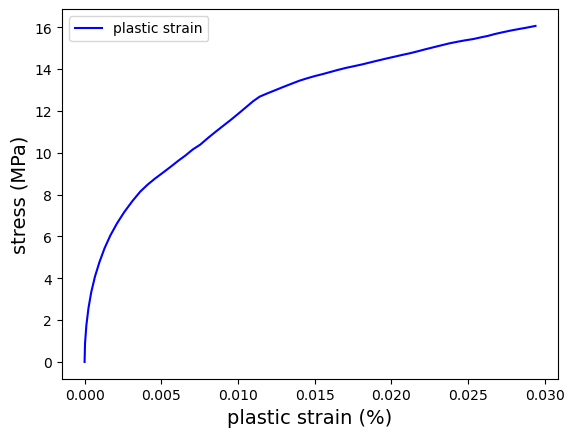


Configuration: 270 dislocations 10 mobile dislocations
box size: 70.71 micron x  70.71 micron
total dislocation density:  0.054001035739865505 /micron^2
mobile dislocation density:  0.0020000383607357594 /micron^2


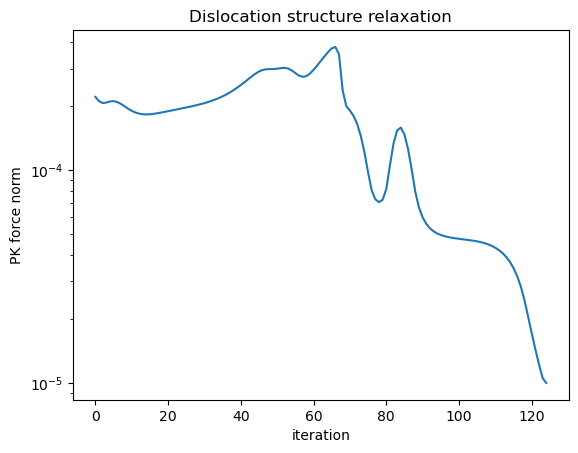

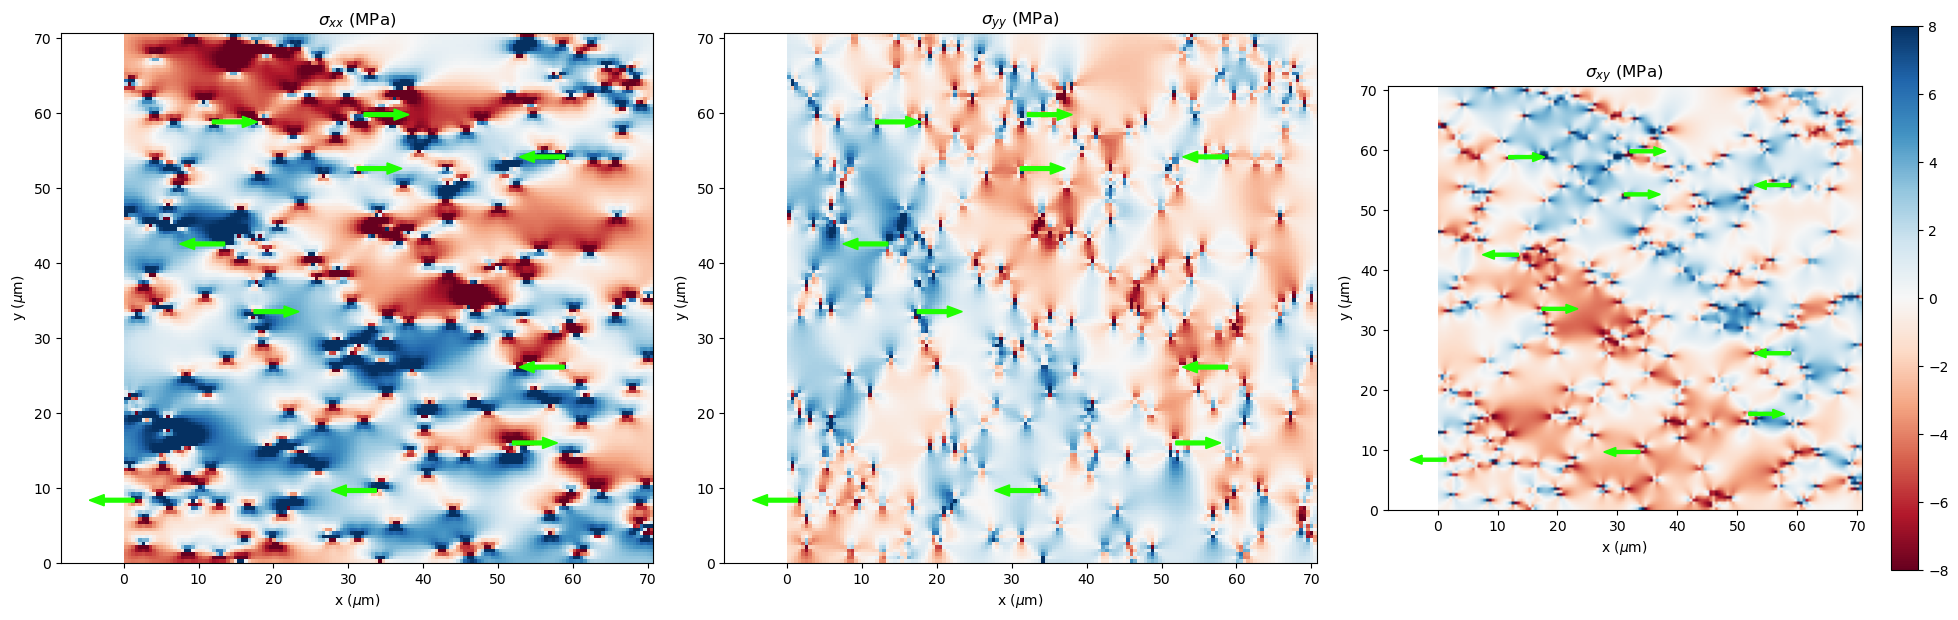

Relaxed dislocation configuration

Virtual dynamic tensile test with loading rate  0.09999999999999999 /s
Performing 100000 iterations with initial sim_time step 0.05

Iteration 	| stress 	| plastic strain	| Time step 
---------------------------------------------------------------------------------
10000		| 8.69249	| 5.30972e-05		| 0.09848
20000		| 10.99166	| 1.09314e-04		| 0.07107
30000		| 12.91755	| 1.59756e-04		| 0.06966
40000		| 13.83617	| 2.13685e-04		| 0.05530
50000		| 14.34673	| 2.63902e-04		| 0.06624


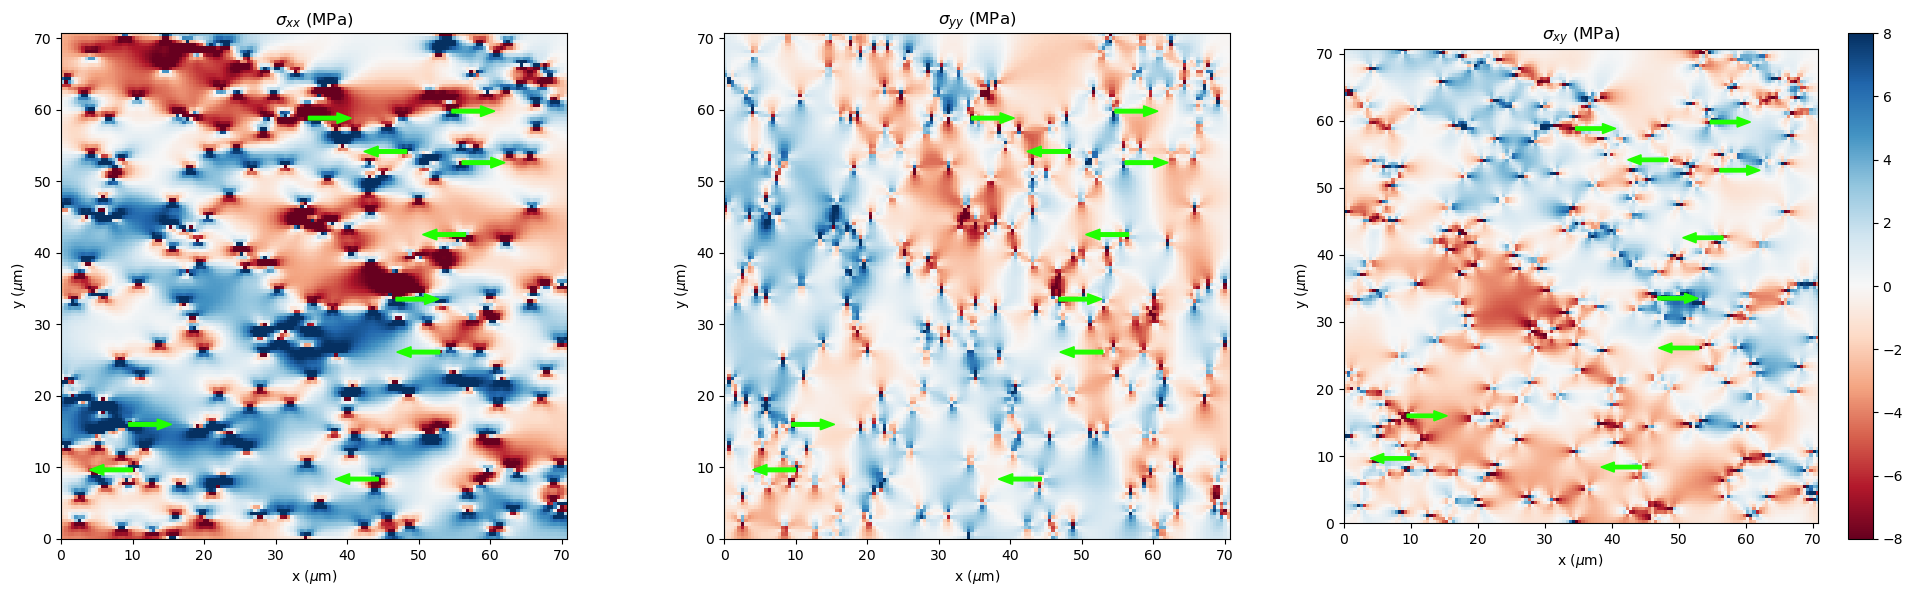

Configuration after 59455 iterations at total strain 0.0005000011424339822
Time step in last iteration:  0.06492540717534037


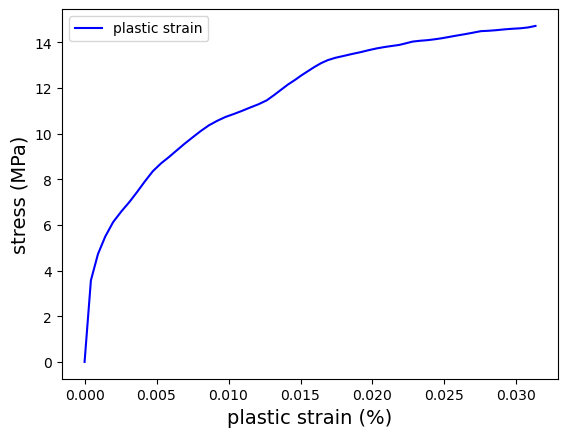

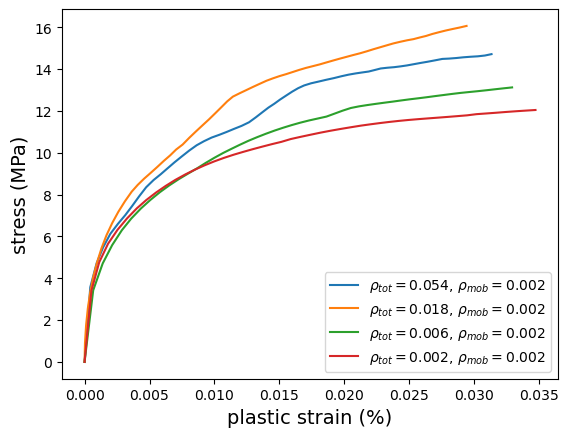

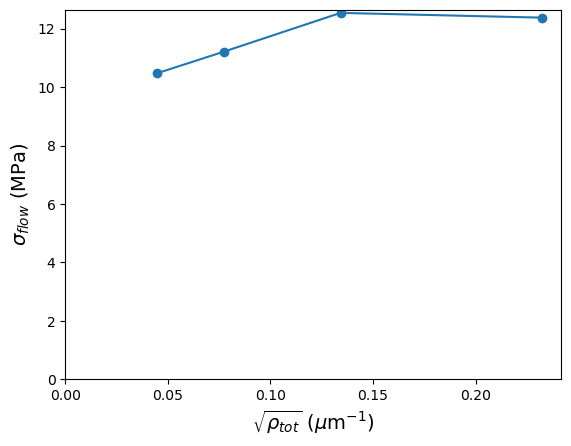

In [4]:
#box geometry
LX = 70.71             # box dimension in x-direction
LY = 70.71             # box dimension in y-direction
bc = 'pbc'            # set boundary conditions: 'fixed' or 'pbc'
#initialze random number generator
np.random.seed(110)  # seed RNG
rt_rho = []
sy = []
eps = []
sig = []
label = []
Nmob = 10
Nlist = [10, 30, 90, 270]

for Ntot in Nlist:
    #define dislocations
    dsl = Dislocations(Ntot, Nmob, spang, C, b0, 
                       LX=LY, LY=LY, bc=bc, 
                       f0=f0, dmob=mob) 
    dsl.positions(stol=1.e-3)   # initialize positions randomly
    print('\n===============================================================')
    print('Configuration:', dsl.Ntot,'dislocations', dsl.Nmob,'mobile dislocations')
    print('box size:',dsl.lx,'micron x ',dsl.ly,'micron')
    print('total dislocation density: ',dsl.rho,'/micron^2')
    print('mobile dislocation density: ',dsl.rho_m,'/micron^2')

    dsl.relax_disl(ftol=1.e-5, plot_conf=False)  # relax dislocations into force equilibrium
    dsl.plot_stress()
    print('Relaxed dislocation configuration\n')
    print('Virtual dynamic tensile test with loading rate ',edot*1e6,'/s')
    print('Performing',nstep,'iterations with initial sim_time step', dt0)
    print('\nIteration \t| stress \t| plastic strain\t| Time step ')
    print('---------------------------------------------------------------------------------')
    #initialize variables
    tau0 = 0.     # macro shear stress
    epl  = 0.     # plastic strain
    etot = 0.     # total strain
    sig_m = [0.]   # initialize list for stress values for postprocessing 
    epl_m = [0.]
    eps_m = [0.]
    ic = 0
    Cpl = dsl.rho_m*b0  # prefactor for Orowan law
    while etot<efin and ic<nstep:
        etot +=edot*dt
        tau0 = mu*(etot-epl)
        fsp, dt = dsl.move_disl(tau0, Nmob, moblaw, dt)
        #calculate plastic slip
        dgpl = Cpl*(np.dot(dsl.dx,dsl.bx) + np.dot(dsl.dy,dsl.by))
        epl += dgpl
        if epl>etot:
            print('Warning: check sim_time step', ic, dgpl, tau0, epl, etot, f0)
        ic += 1
        if ic%idat==0:
            sig_m.append(tau0)
            eps_m.append(etot)
            epl_m.append(epl)
            if ic%ipl==0:
                #dsl.plot_stress()
                print(f'{ic}\t\t| {tau0:.5f}\t| {epl:.5e}\t\t| {dt:.5f}')
    dsl.plot_stress() 
    print('Configuration after',ic,'iterations at total strain',etot)
    print('Time step in last iteration: ',dt) 
    
    epl_m = np.array(epl_m)
    sig_m = np.array(sig_m)
    eps_m = np.array(eps_m)
    plt.plot(epl_m*100,sig_m,'b',label='plastic strain')
    plt.xlabel('plastic strain (%)',fontsize=14)
    plt.ylabel('stress (MPa)',fontsize=14)
    plt.legend()
    plt.show()
    
    eps.append(epl_m)
    sig.append(sig_m)
    rt_rho.append(np.sqrt(dsl.rho))
    i0 = int(len(sig_m)*0.1)
    sy.append(np.average(sig_m[i0:]))
    label.append(r'$\rho_{tot}=$'+f'{dsl.rho:.3f}, '+r'$\rho_{mob}=$'+f'{dsl.rho_m:.3f}')

#plot stress strain curves
for i in range(len(Nlist)-1,-1,-1):
    plt.plot(eps[i]*100,sig[i],label=label[i])
plt.xlabel('plastic strain (%)',fontsize=14)
plt.ylabel('stress (MPa)',fontsize=14)
plt.legend()
plt.show()

#plot flow stress again sqrt of total disl. density
plt.plot(rt_rho,sy,'-o')
plt.xlim(left=0.)
plt.ylim(bottom=0.)
plt.xlabel(r'$\sqrt{\rho_{tot}}$ ($\mu$m$^{-1}$)',fontsize=14)
plt.ylabel(r'$\sigma_{flow}$ (MPa)',fontsize=14)
plt.show()

It is seen that the Taylor relation is fulfilled except for the highest dislocation density. Furthermore, the increase in flow stress with dislocation density is significantly smaller than in the first case. Moreover, the flow stress for low dislocation densities is significantly higher than in the first case which possibly results from a stronger elastic interaction of the mobile dislocations due to close encounters in a relatively smaller box.